<div style="background: linear-gradient(135deg, #1a0030 0%, #2d0050 50%, #1a0040 100%); padding: 48px 40px; border-radius: 16px; margin-bottom: 8px; border: 1px solid #4a0080;">
  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 2px; padding: 4px 12px; border-radius: 20px; text-transform: uppercase;">ML Series · Episode 45</span>
  </div>
  <h1 style="color: #ffffff; font-size: 38px; font-weight: 800; margin: 0 0 12px 0; line-height: 1.2;">🤖 Support Vector Machines</h1>
  <p style="color: #d8b4fe; font-size: 16px; margin: 0 0 6px 0; font-style: italic;">"Don't just separate the classes — separate them with the maximum possible margin."</p>
  <p style="color: #c4b5fd; font-size: 15px; margin: 0 0 28px 0; max-width: 680px; line-height: 1.6;">From hard-margin linear separability to kernel tricks in infinite-dimensional space — a complete tour of SVM theory and practice with GridSearchCV tuning.</p>
  <div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #4a0080; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #a855f7; font-size: 20px; font-weight: 700;">Max Margin</div>
      <div style="color: #d8b4fe; font-size: 12px; margin-top: 2px;">Core SVM objective</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #4a0080; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #a855f7; font-size: 20px; font-weight: 700;">Kernel Trick</div>
      <div style="color: #d8b4fe; font-size: 12px; margin-top: 2px;">Non-linear boundaries</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #4a0080; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #a855f7; font-size: 20px; font-weight: 700;">GridSearchCV</div>
      <div style="color: #d8b4fe; font-size: 12px; margin-top: 2px;">Automated hyperparameter tuning</div>
    </div>
  </div>
</div>

<div style="background: #0d0020; border-left: 5px solid #a855f7; border-radius: 0 10px 10px 0; padding: 20px 24px; margin: 24px 0; border: 1px solid #4a0080; border-left: 5px solid #a855f7;">
  <h2 style="color: #a855f7; font-size: 15px; font-weight: 700; text-transform: uppercase; letter-spacing: 1.5px; margin: 0 0 10px 0;">📋 Table of Contents</h2>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 4px;">
    <ol style="margin: 0; padding-left: 20px; color: #c084fc; line-height: 2.1; font-size: 14px;">
      <li><a href='#intro' style='color: #c084fc; text-decoration: none;'>What is SVM?</a></li>
      <li><a href='#intuition' style='color: #c084fc; text-decoration: none;'>The Core Intuition</a></li>
      <li><a href='#hyperplane' style='color: #c084fc; text-decoration: none;'>Hyperplane &amp; Decision Boundary</a></li>
      <li><a href='#margin' style='color: #c084fc; text-decoration: none;'>Maximum Margin — The Math</a></li>
      <li><a href='#sv' style='color: #c084fc; text-decoration: none;'>Support Vectors</a></li>
      <li><a href='#soft' style='color: #c084fc; text-decoration: none;'>Soft Margin &amp; the C Parameter</a></li>
      <li><a href='#kernel' style='color: #c084fc; text-decoration: none;'>The Kernel Trick</a></li>
    </ol>
    <ol start="8" style="margin: 0; padding-left: 20px; color: #c084fc; line-height: 2.1; font-size: 14px;">
      <li><a href='#setup' style='color: #c084fc; text-decoration: none;'>Imports, Data &amp; Preprocessing</a></li>
      <li><a href='#linear-svm' style='color: #c084fc; text-decoration: none;'>Linear SVM</a></li>
      <li><a href='#c-effect' style='color: #c084fc; text-decoration: none;'>Effect of C — Boundary Plots</a></li>
      <li><a href='#rbf' style='color: #c084fc; text-decoration: none;'>RBF Kernel &amp; Gamma</a></li>
      <li><a href='#tuning' style='color: #c084fc; text-decoration: none;'>GridSearchCV Hyperparameter Tuning</a></li>
      <li><a href='#eval' style='color: #c084fc; text-decoration: none;'>Final Model Evaluation</a></li>
      <li><a href='#compare' style='color: #c084fc; text-decoration: none;'>SVM vs KNN vs Logistic Regression</a></li>
    </ol>
  </div>
</div>

<a id='intro'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 1</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">📌 What is SVM?</h2>
</div>

**Support Vector Machine (SVM)** is a supervised machine learning algorithm primarily used for classification — though it can also handle regression (SVR). It was developed by Vladimir Vapnik and colleagues in the 1990s and remains one of the most theoretically elegant and practically effective classifiers.

<div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 12px; padding: 22px 28px; margin: 20px 0;">
  <div style="color: #c4b5fd; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 14px;">The Core Idea</div>
  <div style="color: #f0e6ff; font-size: 18px; font-family: Georgia, serif; text-align: center; margin-bottom: 14px; font-weight: 600;">
    Find the decision boundary that separates classes<br/>with the <span style="color: #a855f7;">largest possible margin</span>.
  </div>
  <div style="color: #d8b4fe; font-size: 13px; line-height: 1.7; text-align: center;">
    Unlike most classifiers that just try to separate classes, SVM specifically seeks the <strong style='color:#f0e6ff;'>optimal</strong> separating boundary — not just any boundary, but the <strong style='color:#f0e6ff;'>widest</strong> one.
  </div>
</div>

<div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 12px; margin: 16px 0;">
  <div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 8px; padding: 14px 16px; text-align: center;">
    <div style="font-size: 22px; margin-bottom: 6px;">📊</div>
    <div style="color: #a855f7; font-weight: 700; font-size: 13px;">Classification</div>
    <div style="color: #d8b4fe; font-size: 12px; margin-top: 4px;">Primary use case — binary and multi-class</div>
  </div>
  <div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 8px; padding: 14px 16px; text-align: center;">
    <div style="font-size: 22px; margin-bottom: 6px;">📈</div>
    <div style="color: #a855f7; font-weight: 700; font-size: 13px;">SVR</div>
    <div style="color: #d8b4fe; font-size: 12px; margin-top: 4px;">Also works for regression tasks</div>
  </div>
  <div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 8px; padding: 14px 16px; text-align: center;">
    <div style="font-size: 22px; margin-bottom: 6px;">🔬</div>
    <div style="color: #a855f7; font-weight: 700; font-size: 13px;">Small/Medium Data</div>
    <div style="color: #d8b4fe; font-size: 12px; margin-top: 4px;">Shines with high-dimensional, limited-sample problems</div>
  </div>
</div>

<a id='intuition'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 2</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🧠 The Core Intuition</h2>
</div>

Consider two classes (🔵 and 🔴) that are linearly separable. There are **infinitely many lines** that could separate them. Which one should we choose?

<div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 12px; padding: 24px 30px; margin: 20px 0;">
  <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 16px;">
    <div style="border: 1px solid #4a0080; border-radius: 8px; padding: 14px; text-align: center;">
      <div style="color: #e74c3c; font-size: 13px; font-weight: 700; margin-bottom: 6px;">❌ Too Close to 🔴</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.6;">A slight perturbation of a new red point crosses the boundary → misclassification. Fragile.</div>
    </div>
    <div style="border: 1px solid #a855f7; border-radius: 8px; padding: 14px; text-align: center;">
      <div style="color: #a855f7; font-size: 13px; font-weight: 700; margin-bottom: 6px;">✅ Maximum Margin</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.6;">Equidistant from both classes. Maximum buffer zone. Most robust to noise. SVM's choice.</div>
    </div>
    <div style="border: 1px solid #4a0080; border-radius: 8px; padding: 14px; text-align: center;">
      <div style="color: #e74c3c; font-size: 13px; font-weight: 700; margin-bottom: 6px;">❌ Too Close to 🔵</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.6;">Same problem from the other side. Correctly separates training data but won't generalise.</div>
    </div>
  </div>
  <div style="margin-top: 16px; padding-top: 14px; border-top: 1px solid #4a0080; color: #a855f7; font-size: 14px; text-align: center; font-family: Georgia, serif;">
    The maximum-margin boundary is the most robust to small perturbations → better generalisation.
  </div>
</div>

<a id='hyperplane'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 3</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">📐 Hyperplane &amp; Decision Boundary</h2>
</div>

In 2D, the decision boundary is a **line**. In 3D, it's a **plane**. In n dimensions, it's a **hyperplane** — a flat subspace of dimension (n−1).

<div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 12px; padding: 24px 30px; margin: 20px 0;">
  <div style="color: #c4b5fd; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 16px;">Hyperplane Equation</div>
  <div style="display: flex; flex-direction: column; gap: 14px;">
    <div>
      <div style="color: #c4b5fd; font-size: 12px; margin-bottom: 4px;">Decision boundary (2D: line, nD: hyperplane)</div>
      <div style="color: #f0e6ff; font-size: 18px; font-family: Georgia, serif;">w₁x₁ + w₂x₂ + b = 0 &nbsp;&nbsp;→&nbsp;&nbsp; wᵀx + b = 0</div>
    </div>
    <div>
      <div style="color: #c4b5fd; font-size: 12px; margin-bottom: 4px;">Positive and negative margin boundaries</div>
      <div style="color: #f0e6ff; font-size: 18px; font-family: Georgia, serif;">wᵀx + b = +1 &nbsp;&nbsp;and&nbsp;&nbsp; wᵀx + b = −1</div>
    </div>
    <div>
      <div style="color: #c4b5fd; font-size: 12px; margin-bottom: 4px;">Classification rule</div>
      <div style="color: #a855f7; font-size: 17px; font-family: Georgia, serif;">ŷ = +1 if wᵀx + b &gt; 0 &nbsp;&nbsp;|&nbsp;&nbsp; ŷ = −1 if wᵀx + b &lt; 0</div>
    </div>
  </div>
  <div style="margin-top: 14px; padding-top: 12px; border-top: 1px solid #4a0080; color: #d8b4fe; font-size: 12px;">
    <strong style='color:#a855f7;'>w</strong> = weight vector (normal to the hyperplane) · <strong style='color:#a855f7;'>b</strong> = bias/intercept term · <strong style='color:#a855f7;'>x</strong> = input feature vector
  </div>
</div>

<a id='margin'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 4</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🎯 Maximum Margin — The Math</h2>
</div>

The margin is the distance between the two boundary lines (`wᵀx + b = +1` and `wᵀx + b = −1`). Maximising this margin leads to an elegant optimisation problem:

<div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 12px; padding: 24px 30px; margin: 20px 0;">
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 24px;">
    <div>
      <div style="color: #c4b5fd; font-size: 11px; letter-spacing: 1px; text-transform: uppercase; margin-bottom: 10px;">Width of Margin</div>
      <div style="color: #f0e6ff; font-size: 20px; font-family: Georgia, serif; margin-bottom: 8px;">margin = 2 / ‖w‖</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.6;">Larger margin ← smaller ‖w‖. To maximise the margin, we minimise the norm of the weight vector.</div>
    </div>
    <div>
      <div style="color: #c4b5fd; font-size: 11px; letter-spacing: 1px; text-transform: uppercase; margin-bottom: 10px;">Optimisation Objective</div>
      <div style="color: #a855f7; font-size: 18px; font-family: Georgia, serif; margin-bottom: 8px;">minimise &nbsp; ½‖w‖²</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.6;">Subject to: yᵢ(wᵀxᵢ + b) ≥ 1 for all training points. This is a convex quadratic program — guaranteed to have a unique global optimum.</div>
    </div>
  </div>
  <div style="margin-top: 14px; padding-top: 12px; border-top: 1px solid #4a0080; background: rgba(168,85,247,0.08); border-radius: 6px; padding: 12px 16px;">
    <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 4px;">💡 Key insight</div>
    <div style="color: #d8b4fe; font-size: 13px;">This is a <strong style='color:#f0e6ff;'>convex optimisation problem</strong> — unlike neural networks, SVM has no local minima. The solution is always the global optimum. This makes SVM theoretically very appealing.</div>
  </div>
</div>

<a id='sv'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 5</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🧱 Support Vectors</h2>
</div>

**Support vectors** are the training samples that lie exactly on the margin boundaries (`wᵀx + b = ±1`). They are the only points that actually define the hyperplane — every other training point is irrelevant.

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin: 16px 0;">
  <div style="background: #0d0020; border: 1px solid #4a0080; border-top: 2px solid #a855f7; border-radius: 0 0 8px 8px; padding: 16px 18px;">
    <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 8px;">🔴 Remove a non-support-vector point</div>
    <div style="color: #d8b4fe; font-size: 13px; line-height: 1.7;">The decision boundary stays exactly the same. That point had zero influence on the solution — it was already on the correct side with a comfortable margin.</div>
  </div>
  <div style="background: #0d0020; border: 1px solid #4a0080; border-top: 2px solid #e74c3c; border-radius: 0 0 8px 8px; padding: 16px 18px;">
    <div style="color: #e74c3c; font-weight: 700; font-size: 13px; margin-bottom: 8px;">🔺 Remove a support vector</div>
    <div style="color: #d8b4fe; font-size: 13px; line-height: 1.7;">The boundary can change significantly — the margin may shift, rotate, or widen in that direction. Support vectors are the critical points that define the solution.</div>
  </div>
</div>

<div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #d8b4fe;">
  <strong style="color: #a855f7;">💡 Sparsity property:</strong> Only a small fraction of training points become support vectors. The final SVM model is entirely defined by this small subset — making it memory-efficient compared to KNN (which stores everything) and giving it strong theoretical properties (VC dimension theory).
</div>

<a id='soft'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 6</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">⚠️ Soft Margin &amp; the C Parameter</h2>
</div>

Real-world data is almost never perfectly linearly separable — there's always noise, outliers, and class overlap. The **hard-margin SVM** (no misclassifications allowed) fails on such data. The **soft-margin SVM** introduces slack variables ξᵢ that allow some misclassifications, controlled by the hyperparameter **C**.

<div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 12px; padding: 22px 28px; margin: 20px 0;">
  <div style="color: #c4b5fd; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 14px;">Soft Margin Objective</div>
  <div style="color: #a855f7; font-size: 17px; font-family: Georgia, serif; text-align: center; margin-bottom: 16px;">
    minimise &nbsp; ½‖w‖² + C · Σξᵢ
  </div>
  <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 14px; margin-top: 10px;">
    <div style="background: rgba(168,85,247,0.1); border: 1px solid #4a0080; border-radius: 8px; padding: 14px; text-align: center;">
      <div style="color: #a855f7; font-weight: 800; font-size: 18px; font-family: Georgia;">C → 0</div>
      <div style="color: #e74c3c; font-weight: 700; font-size: 12px; margin: 4px 0;">High Regularization</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.5;">Allows many errors. Wide margin. Simpler boundary. May underfit.</div>
    </div>
    <div style="background: rgba(168,85,247,0.1); border: 2px solid #a855f7; border-radius: 8px; padding: 14px; text-align: center;">
      <div style="color: #a855f7; font-weight: 800; font-size: 18px; font-family: Georgia;">C = 1</div>
      <div style="color: #22c55e; font-weight: 700; font-size: 12px; margin: 4px 0;">Balanced ✦ Default</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.5;">Moderate trade-off. Good starting point. Tune via cross-validation.</div>
    </div>
    <div style="background: rgba(168,85,247,0.1); border: 1px solid #4a0080; border-radius: 8px; padding: 14px; text-align: center;">
      <div style="color: #a855f7; font-weight: 800; font-size: 18px; font-family: Georgia;">C → ∞</div>
      <div style="color: #f0a500; font-weight: 700; font-size: 12px; margin: 4px 0;">Low Regularization</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.5;">Penalises every error heavily. Narrow margin. May overfit to noise.</div>
    </div>
  </div>
</div>

<a id='kernel'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 7</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🌐 The Kernel Trick</h2>
</div>

A linear SVM only creates a linear boundary. But many real problems aren't linearly separable — think concentric circles or XOR patterns. The solution: **map the data to a higher-dimensional space** where it becomes linearly separable, then find the hyperplane there.

<div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 12px; padding: 22px 28px; margin: 20px 0;">
  <div style="color: #c4b5fd; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 14px;">The Trick — Implicit Transformation</div>
  <div style="color: #d8b4fe; font-size: 13px; line-height: 1.7; margin-bottom: 14px;">
    Explicitly transforming millions of points to high-dimensional space is computationally expensive. The kernel trick avoids this entirely:
    SVM only ever needs <strong style='color:#f0e6ff;'>dot products</strong> between data points. A kernel function computes these dot products
    <strong style='color:#a855f7;'>in the transformed space without ever transforming the data explicitly</strong>.
  </div>
  <div style="color: #a855f7; font-size: 16px; font-family: Georgia, serif; text-align: center; margin-bottom: 14px;">
    K(xᵢ, xⱼ) = φ(xᵢ)ᵀ φ(xⱼ) &nbsp;&nbsp; computed cheaply!
  </div>
  <div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 10px; overflow: hidden;">
    <table style="width: 100%; border-collapse: collapse; font-size: 13px;">
      <thead>
        <tr style="background: #2d0050;">
          <th style="padding: 10px 16px; color: #a855f7; text-align: left;">Kernel</th>
          <th style="padding: 10px 16px; color: #a855f7; text-align: left;">Formula</th>
          <th style="padding: 10px 16px; color: #a855f7; text-align: left;">Best For</th>
        </tr>
      </thead>
      <tbody>
        <tr style="border-bottom: 1px solid #4a0080;"><td style="padding: 9px 16px; color: #f0e6ff; font-weight: 600;">linear</td><td style="padding: 9px 16px; color: #d8b4fe; font-family: Georgia;">xᵢᵀxⱼ</td><td style="padding: 9px 16px; color: #d8b4fe;">Linearly separable, high-dim text/image data</td></tr>
        <tr style="border-bottom: 1px solid #4a0080; background: rgba(168,85,247,0.04);"><td style="padding: 9px 16px; color: #f0e6ff; font-weight: 600;">poly</td><td style="padding: 9px 16px; color: #d8b4fe; font-family: Georgia;">(γxᵢᵀxⱼ + r)ᵈ</td><td style="padding: 9px 16px; color: #d8b4fe;">Polynomial relationships between features</td></tr>
        <tr style="border-bottom: 1px solid #4a0080;"><td style="padding: 9px 16px; color: #f0e6ff; font-weight: 600;">rbf ⭐</td><td style="padding: 9px 16px; color: #d8b4fe; font-family: Georgia;">exp(−γ‖xᵢ−xⱼ‖²)</td><td style="padding: 9px 16px; color: #d8b4fe;">General-purpose — most commonly used non-linear kernel</td></tr>
        <tr><td style="padding: 9px 16px; color: #f0e6ff; font-weight: 600;">sigmoid</td><td style="padding: 9px 16px; color: #d8b4fe; font-family: Georgia;">tanh(γxᵢᵀxⱼ + r)</td><td style="padding: 9px 16px; color: #d8b4fe;">Neural-network-like boundaries (rarely best choice)</td></tr>
      </tbody>
    </table>
  </div>
</div>

<a id='setup'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 8</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🧪 Imports, Data &amp; Preprocessing</h2>
</div>

We generate a 2D synthetic classification dataset with `make_classification` — 2 features means we can plot the decision boundary directly. We use `class_sep=1.5` to make the classes partially overlapping (not trivially separable).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

np.random.seed(42)

Dataset shape : (500, 2)
Class balance : [249 251]


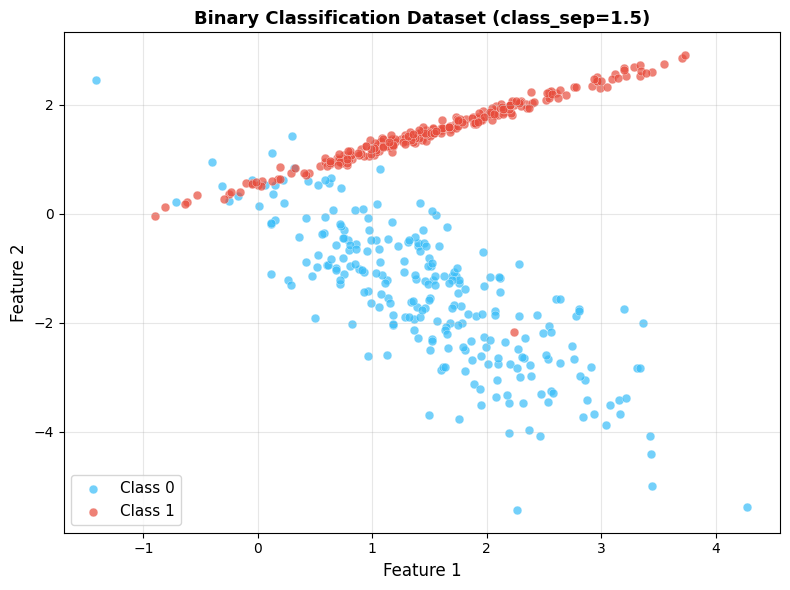

In [2]:
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

print(f"Dataset shape : {X.shape}")
print(f"Class balance : {np.bincount(y)}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X[y == 0, 0], X[y == 0, 1], alpha=0.7, s=40,
           color='#38bdf8', edgecolors='white', linewidth=0.3, label='Class 0')
ax.scatter(X[y == 1, 0], X[y == 1, 1], alpha=0.7, s=40,
           color='#e74c3c', edgecolors='white', linewidth=0.3, label='Class 1')
ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title('Binary Classification Dataset (class_sep=1.5)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale — mandatory for SVM (distance/dot-product based)
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)          # transform test with same stats

print(f"Train : {X_train_scaled.shape}  |  Test : {X_test_scaled.shape}")

Train : (400, 2)  |  Test : (100, 2)


<a id='linear-svm'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 9</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🤖 Linear SVM — Baseline</h2>
</div>

We start with a **linear kernel** — the simplest case. If the data is linearly separable (or close to it), this is often sufficient and very fast to train. The `C=1.0` is the default soft-margin penalty.

In [4]:
linear_svm = SVC(kernel='linear', C=1.0)
linear_svm.fit(X_train_scaled, y_train)

y_pred_lin = linear_svm.predict(X_test_scaled)
acc_lin    = accuracy_score(y_test, y_pred_lin)

print(f"Linear SVM Accuracy    : {acc_lin:.4f}")
print(f"Number of support vectors: {linear_svm.n_support_} (class 0, class 1)")
print(f"Total support vectors  : {len(linear_svm.support_vectors_)}")
print(f"\n{classification_report(y_test, y_pred_lin)}")

Linear SVM Accuracy    : 0.9500
Number of support vectors: [31 31] (class 0, class 1)
Total support vectors  : 62

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        50
           1       0.91      1.00      0.95        50

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100



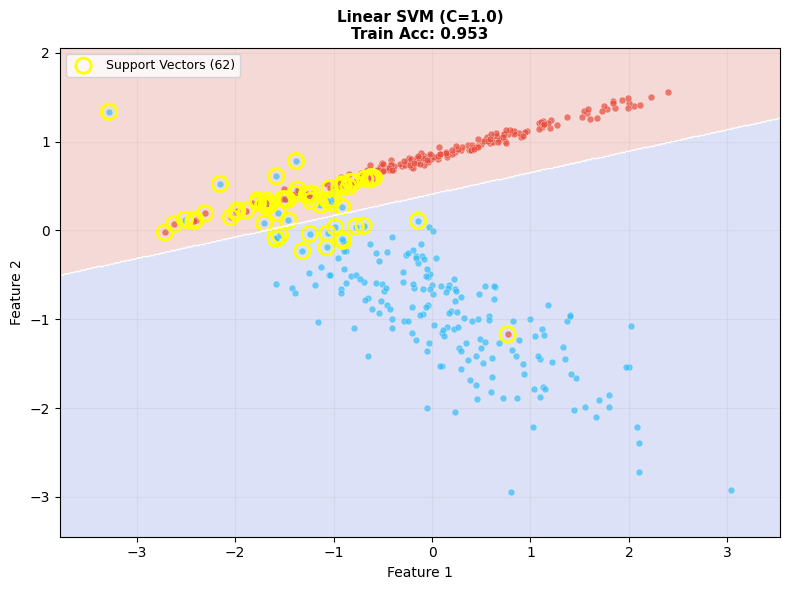

In [5]:
def plot_decision_boundary(model, X, y, title, ax=None):
    """Plot SVM decision boundary and highlight support vectors."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                          np.linspace(y_min, y_max, 400))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
    ax.contour(xx, yy, Z, colors='white', linewidths=1.2, levels=[0.5])

    ax.scatter(X[y == 0, 0], X[y == 0, 1], color='#38bdf8', s=25,
               alpha=0.7, edgecolors='white', linewidth=0.3)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], color='#e74c3c', s=25,
               alpha=0.7, edgecolors='white', linewidth=0.3)

    # Highlight support vectors
    if hasattr(model, 'support_vectors_'):
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                   s=120, facecolors='none', edgecolors='yellow',
                   linewidths=2, label=f'Support Vectors ({len(model.support_vectors_)})')
        ax.legend(fontsize=9, loc='upper left')

    acc = accuracy_score(y, model.predict(X))
    ax.set_title(f'{title}\nTrain Acc: {acc:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.2)

plot_decision_boundary(linear_svm, X_train_scaled, y_train, 'Linear SVM (C=1.0)')
plt.tight_layout()
plt.show()

<a id='c-effect'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 10</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🧱 Effect of C — Boundary Plots</h2>
</div>

The 4-panel plot below makes the C effect visually obvious. Watch how the number of support vectors (yellow circles) changes — smaller C → wider margin → more support vectors inside the margin.

In [6]:
C_values = [0.01, 0.1, 1, 10, 100]
print(f"{'C':<8} {'Test Accuracy':>14} {'Support Vectors':>16}")
print("-" * 40)
for C in C_values:
    m = SVC(kernel='linear', C=C).fit(X_train_scaled, y_train)
    acc = m.score(X_test_scaled, y_test)
    print(f"{C:<8} {acc:>14.4f} {len(m.support_vectors_):>16}")

C         Test Accuracy  Support Vectors
----------------------------------------
0.01             0.9300              230
0.1              0.9500              102
1                0.9500               62
10               0.9500               55
100              0.9500               53


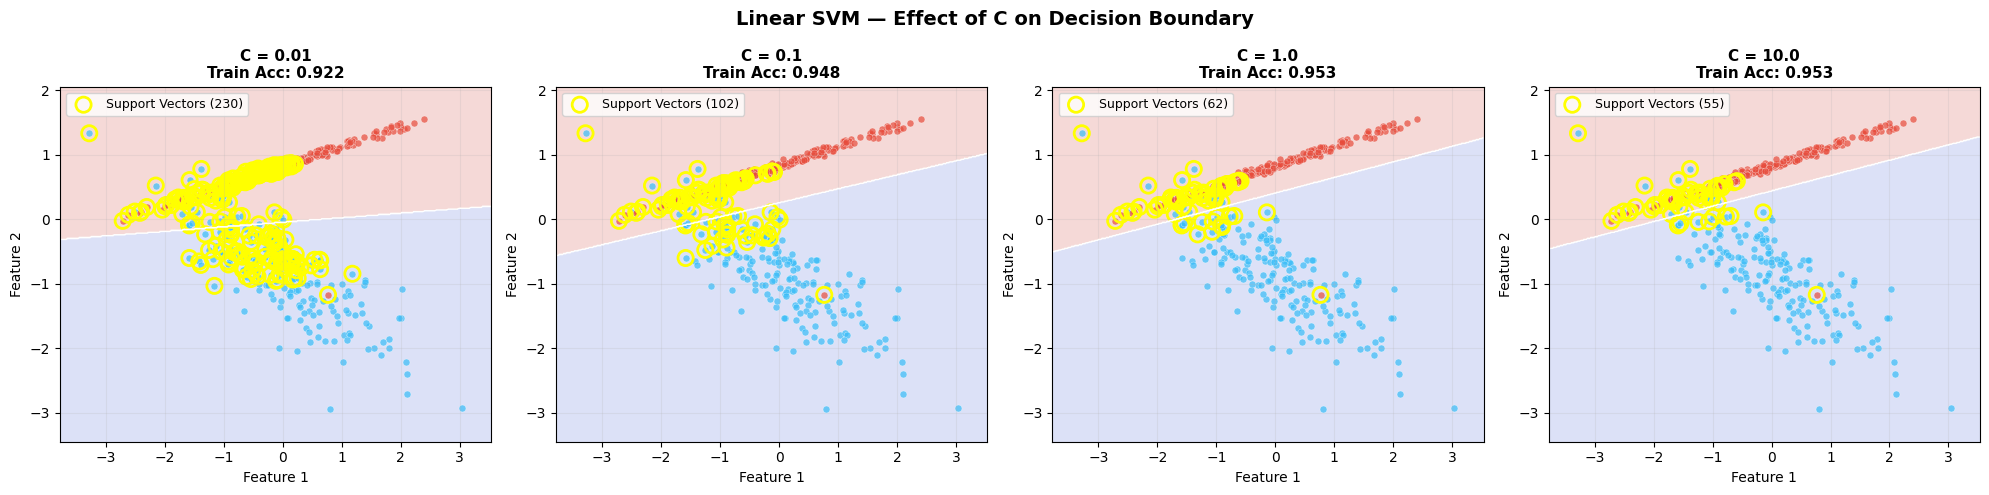

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Linear SVM — Effect of C on Decision Boundary', fontsize=14, fontweight='bold')

for ax, C in zip(axes, [0.01, 0.1, 1.0, 10.0]):
    m = SVC(kernel='linear', C=C).fit(X_train_scaled, y_train)
    plot_decision_boundary(m, X_train_scaled, y_train, f'C = {C}', ax=ax)

plt.tight_layout()
plt.show()

<a id='rbf'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 11</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🌀 RBF Kernel &amp; Gamma</h2>
</div>

The **Radial Basis Function (RBF)** kernel is the go-to choice for non-linear problems. It measures similarity between two points as a Gaussian function of their distance — nearby points have high similarity (close to 1), distant points have low similarity (close to 0).

**Gamma (γ)** controls the "reach" of each training point:
- **Low γ**: wide influence → smooth, simple boundary (may underfit)
- **High γ**: narrow influence → complex, wiggly boundary (may overfit)

In [8]:
rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale')
rbf_svm.fit(X_train_scaled, y_train)

y_pred_rbf = rbf_svm.predict(X_test_scaled)
print(f"RBF SVM Accuracy : {accuracy_score(y_test, y_pred_rbf):.4f}")
print(f"Support Vectors  : {rbf_svm.n_support_}")

RBF SVM Accuracy : 0.9500
Support Vectors  : [34 32]


In [9]:
gamma_values = [0.01, 0.1, 1, 10]
print(f"{'Gamma':<10} {'Test Accuracy':>14} {'Support Vectors':>16}")
print("-" * 42)
for g in gamma_values:
    m = SVC(kernel='rbf', C=1, gamma=g).fit(X_train_scaled, y_train)
    acc = m.score(X_test_scaled, y_test)
    print(f"{g:<10} {acc:>14.4f} {len(m.support_vectors_):>16}")

Gamma       Test Accuracy  Support Vectors
------------------------------------------
0.01               0.9400              179
0.1                0.9500               84
1                  0.9500               66
10                 0.9500              139


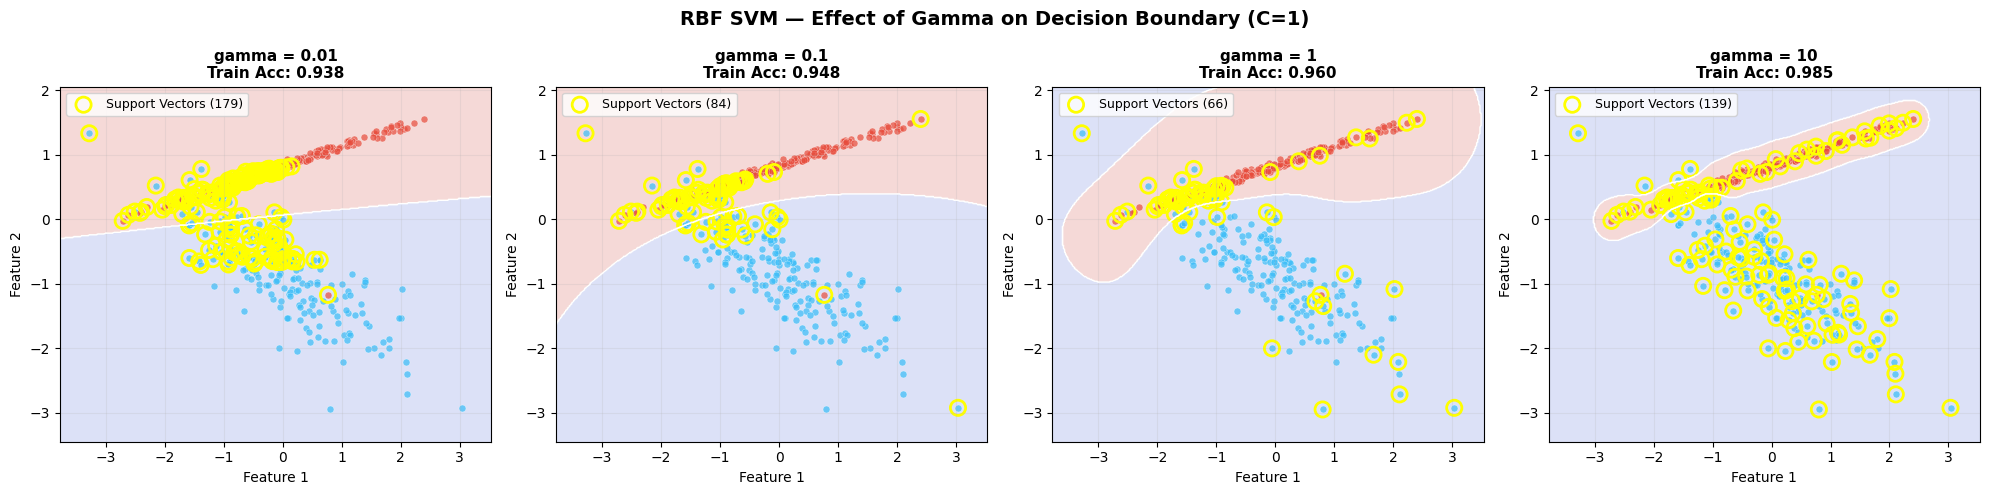

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('RBF SVM — Effect of Gamma on Decision Boundary (C=1)', fontsize=14, fontweight='bold')

for ax, g in zip(axes, gamma_values):
    m = SVC(kernel='rbf', C=1, gamma=g).fit(X_train_scaled, y_train)
    plot_decision_boundary(m, X_train_scaled, y_train, f'gamma = {g}', ax=ax)

plt.tight_layout()
plt.show()

<a id='tuning'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 12</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">⚙️ GridSearchCV Hyperparameter Tuning</h2>
</div>

Instead of trying combinations manually, **GridSearchCV** exhaustively tests all parameter combinations with k-fold cross-validation and picks the best one. For SVM the key parameters are `C`, `gamma`, and `kernel`.

<div style="background: #0d0020; border: 1px solid #4a0080; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #d8b4fe;">
  <strong style="color: #a855f7;">⚠️ Note:</strong> GridSearchCV should be fit on <code>X_train_scaled</code> — never on the full dataset. The test set must remain completely unseen during all hyperparameter search steps. We use <code>cv=5</code> (5-fold cross-validation on the training set).
</div>

In [11]:
param_grid = {
    'C':      [0.01, 0.1, 1, 10, 100],
    'gamma':  ['scale', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest Parameters  : {grid_search.best_params_}")
print(f"Best CV Score    : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters  : {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
Best CV Score    : 0.9750


In [12]:
# Visualise top 10 parameter combinations
results = pd.DataFrame(grid_search.cv_results_)
top10   = results.nlargest(10, 'mean_test_score')[['param_kernel', 'param_C', 'param_gamma',
                                                     'mean_test_score', 'std_test_score']]
top10.columns = ['Kernel', 'C', 'Gamma', 'CV Mean Acc', 'CV Std']
top10 = top10.round(4).reset_index(drop=True)
print("Top 10 Parameter Combinations:")
print(top10.to_string(index=False))

Top 10 Parameter Combinations:
Kernel     C  Gamma  CV Mean Acc  CV Std
   rbf 100.0      1       0.9750  0.0209
   rbf  10.0      1       0.9700  0.0150
   rbf 100.0  scale       0.9675  0.0187
   rbf  10.0  scale       0.9650  0.0166
   rbf   1.0      1       0.9600  0.0122
   rbf 100.0    0.1       0.9600  0.0122
   rbf   0.1      1       0.9575  0.0127
linear 100.0  scale       0.9575  0.0100
linear 100.0  0.001       0.9575  0.0100
linear 100.0   0.01       0.9575  0.0100


<a id='eval'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 13</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">📈 Final Model Evaluation</h2>
</div>

In [13]:
best_svm  = grid_search.best_estimator_
y_pred    = best_svm.predict(X_test_scaled)
acc_final = accuracy_score(y_test, y_pred)

print(f"Best Model    : {grid_search.best_params_}")
print(f"Test Accuracy : {acc_final:.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

Best Model    : {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
Test Accuracy : 0.9600

              precision    recall  f1-score   support

     Class 0       1.00      0.92      0.96        50
     Class 1       0.93      1.00      0.96        50

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



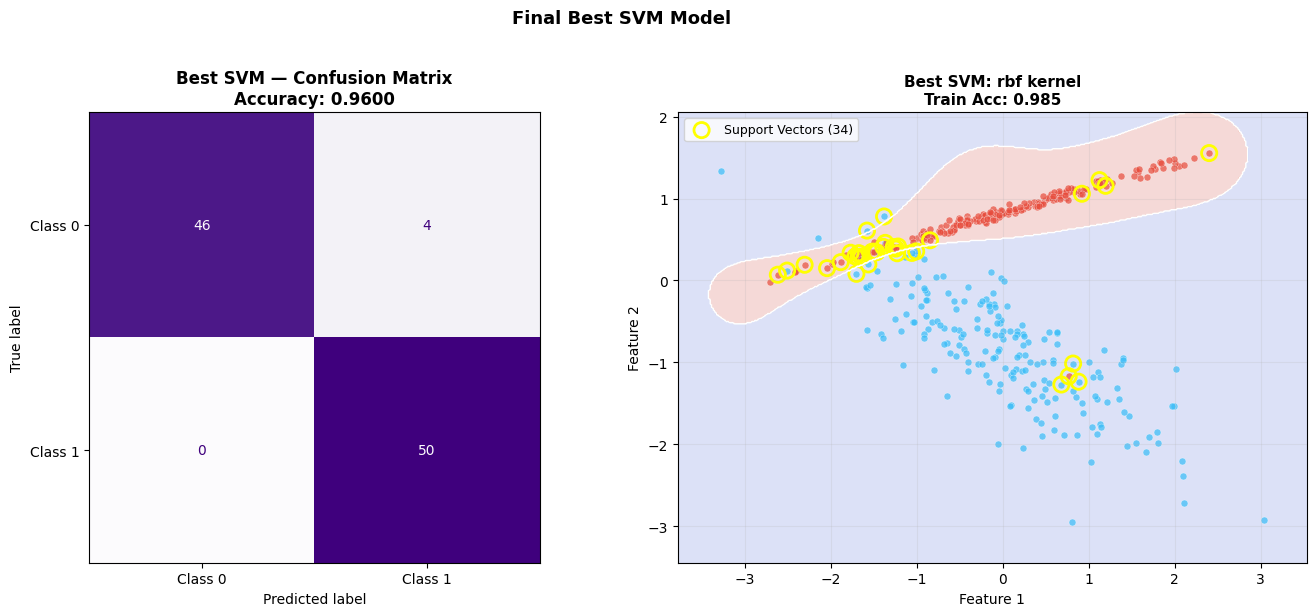

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(ax=axes[0], colorbar=False, cmap='Purples')
axes[0].set_title(f'Best SVM — Confusion Matrix\nAccuracy: {acc_final:.4f}', fontweight='bold')

# Decision boundary of best model
plot_decision_boundary(best_svm, X_train_scaled, y_train,
                       f"Best SVM: {grid_search.best_params_['kernel']} kernel", ax=axes[1])

plt.suptitle('Final Best SVM Model', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# Support vector analysis
print("Support Vector Analysis — Best Model")
print("-" * 40)
print(f"Per-class support vectors : {best_svm.n_support_}")
print(f"Total support vectors     : {len(best_svm.support_vectors_)}")
print(f"Fraction of training data : {len(best_svm.support_vectors_)/len(X_train_scaled)*100:.1f}%")
print(f"\nFirst 3 support vectors:")
print(best_svm.support_vectors_[:3].round(4))

Support Vector Analysis — Best Model
----------------------------------------
Per-class support vectors : [15 19]
Total support vectors     : 34
Fraction of training data : 8.5%

First 3 support vectors:
[[-1.5802  0.6086]
 [-1.3817  0.7812]
 [ 0.8816 -1.2367]]


<a id='compare'></a>
<div style="border-bottom: 2px solid #a855f7; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #a855f7; color: #1a0030; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 14</span>
  <h2 style="color: #f0e6ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🧠 SVM vs KNN vs Logistic Regression</h2>
</div>

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN (K=5)':           KNeighborsClassifier(n_neighbors=5),
    'SVM (Linear)':        SVC(kernel='linear', C=1.0),
    'SVM (RBF)':           SVC(kernel='rbf', C=1.0, gamma='scale'),
    'SVM (Best)':          best_svm,
}

print(f"{'Model':<25} {'Test Acc':>10} {'CV Mean':>10} {'CV Std':>8}")
print("-" * 55)
for name, m in models.items():
    if name != 'SVM (Best)':
        m.fit(X_train_scaled, y_train)
    acc  = accuracy_score(y_test, m.predict(X_test_scaled))
    cv   = cross_val_score(m, X_train_scaled, y_train, cv=5)
    print(f"{name:<25} {acc:>10.4f} {cv.mean():>10.4f} {cv.std():>8.4f}")

Model                       Test Acc    CV Mean   CV Std
-------------------------------------------------------
Logistic Regression           0.9700     0.9425   0.0187
KNN (K=5)                     0.9600     0.9700   0.0150
SVM (Linear)                  0.9500     0.9525   0.0094
SVM (RBF)                     0.9500     0.9525   0.0094
SVM (Best)                    0.9600     0.9750   0.0209


<div style="background: linear-gradient(135deg, #1a0030 0%, #2d0050 100%); border: 1px solid #4a0080; border-radius: 14px; padding: 36px 40px; margin-top: 32px;">
  <h2 style="color: #ffffff; font-size: 20px; font-weight: 700; margin: 0 0 8px 0;">📌 Key Concepts &amp; Takeaways</h2>
  <p style="color: #d8b4fe; font-size: 13px; margin: 0 0 20px 0;">Everything that matters about Support Vector Machines.</p>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin-bottom: 20px;">
    <div style="background: rgba(168,85,247,0.08); border: 1px solid #4a0080; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 6px;">📐 Hyperplane</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.7;">The decision boundary separating classes. A line in 2D, plane in 3D, hyperplane in nD. Defined by weight vector <strong style='color:#f0e6ff;'>w</strong> and bias <strong style='color:#f0e6ff;'>b</strong>.</div>
    </div>
    <div style="background: rgba(168,85,247,0.08); border: 1px solid #4a0080; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 6px;">📏 Margin = 2/‖w‖</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.7;">Distance between the two margin boundaries. Maximising margin = minimising ‖w‖². A convex QP with a unique global optimum.</div>
    </div>
    <div style="background: rgba(168,85,247,0.08); border: 1px solid #4a0080; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🧱 Support Vectors</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.7;">The points that define the margin. Only these matter — all others can be removed without changing the solution. Makes SVM memory-sparse.</div>
    </div>
    <div style="background: rgba(168,85,247,0.08); border: 1px solid #4a0080; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🔢 C &amp; Gamma</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.7;">C = regularization (small C = wide margin, allow errors). Gamma = RBF reach (low = smooth, high = complex). Always tune both with GridSearchCV.</div>
    </div>
    <div style="background: rgba(168,85,247,0.08); border: 1px solid #4a0080; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🌐 Kernel Trick</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.7;">Implicitly maps data to higher dimensions via dot products. Enables non-linear boundaries without the cost of explicit transformation. RBF is the default choice.</div>
    </div>
    <div style="background: rgba(168,85,247,0.08); border: 1px solid #4a0080; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 6px;">⚠️ Limitations</div>
      <div style="color: #d8b4fe; font-size: 12px; line-height: 1.7;">Slow on very large datasets (O(n²)–O(n³) training). Black-box — hard to interpret. Requires feature scaling. GridSearchCV essential for good performance.</div>
    </div>
  </div>
  <div style="background: rgba(168,85,247,0.1); border: 1px solid #4a0080; border-radius: 8px; padding: 14px 20px; margin-bottom: 16px;">
    <div style="color: #a855f7; font-weight: 700; font-size: 13px; margin-bottom: 6px;">📊 Algorithm Comparison</div>
    <div style="overflow: hidden; border-radius: 6px;">
      <table style="width: 100%; border-collapse: collapse; font-size: 12px;">
        <tr style="background: #2d0050;"><th style="padding: 8px 12px; color: #a855f7; text-align: left;">Algorithm</th><th style="padding: 8px 12px; color: #a855f7;">Non-linear?</th><th style="padding: 8px 12px; color: #a855f7;">Scaling?</th><th style="padding: 8px 12px; color: #a855f7; text-align: left;">Best For</th></tr>
        <tr style="border-bottom: 1px solid #4a0080;"><td style="padding: 7px 12px; color: #f0e6ff;">Logistic Regression</td><td style="padding: 7px 12px; color: #d8b4fe; text-align: center;">❌</td><td style="padding: 7px 12px; color: #d8b4fe; text-align: center;">Often</td><td style="padding: 7px 12px; color: #d8b4fe;">Interpretable linear boundaries, probability output</td></tr>
        <tr style="border-bottom: 1px solid #4a0080; background: rgba(168,85,247,0.04);"><td style="padding: 7px 12px; color: #f0e6ff;">KNN</td><td style="padding: 7px 12px; color: #d8b4fe; text-align: center;">✅</td><td style="padding: 7px 12px; color: #d8b4fe; text-align: center;">⭐⭐⭐</td><td style="padding: 7px 12px; color: #d8b4fe;">Small datasets, no training time, irregular boundaries</td></tr>
        <tr style="border-bottom: 1px solid #4a0080;"><td style="padding: 7px 12px; color: #f0e6ff;">SVM (linear)</td><td style="padding: 7px 12px; color: #d8b4fe; text-align: center;">❌</td><td style="padding: 7px 12px; color: #d8b4fe; text-align: center;">⭐⭐⭐</td><td style="padding: 7px 12px; color: #d8b4fe;">High-dim text/image, linearly separable</td></tr>
        <tr style="background: rgba(168,85,247,0.08);"><td style="padding: 7px 12px; color: #f0e6ff; font-weight: 700;">SVM (RBF) ✦</td><td style="padding: 7px 12px; color: #d8b4fe; text-align: center;">✅</td><td style="padding: 7px 12px; color: #d8b4fe; text-align: center;">⭐⭐⭐</td><td style="padding: 7px 12px; color: #d8b4fe;">Small/medium datasets with complex boundaries</td></tr>
      </table>
    </div>
  </div>
  <div style="padding-top: 14px; border-top: 1px solid #4a0080; color: #d8b4fe; font-size: 12px;">
    Next up → <a href="https://www.kaggle.com/code/ahmedfakhar123/ml-46-decision-trees-entropy-gini/edit" style='text-decoration: none;'><strong style='color:#a855f7;'>ML 46: Decision Trees — Splitting Criteria, Depth &amp; Pruning</strong></a>
  </div>
</div>